**NOTICE:**  
The U.S. Army Corps of Engineers, Risk Management Center (USACE-RMC) makes no guarantees about the results, or appropriateness of outputs, obtained from Numerics.

# 07. Root Finding and Numerical Integration
This notebook covers root finding and numerical integration methods in Numerics.

## What You'll Learn
- How to bracket and solve 1D roots with bisection and Brent's method
- How fixed-step quadrature rules approximate definite integrals
- How Gauss-Legendre quadrature improves accuracy for smooth functions
- How adaptive methods concentrate effort where the integrand is difficult

## Setup

In [1]:
import pythonnet
pythonnet.load("coreclr")

import clr
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import time
import pandas as pd
from scipy import integrate

# Load Numerics DLL
dll_path = Path(r"C:\GIT\Numerics\Numerics\bin\Debug\net8.0\Numerics.dll")
clr.AddReference(str(dll_path))

from Numerics.Mathematics.RootFinding import Bisection, Brent
from Numerics.Mathematics.Integration import Integration, AdaptiveGaussKronrod, AdaptiveGaussLobatto, AdaptiveSimpsonsRule
from System import Func, Double


## What is Root Finding?
Root finding is the process of determining the values of $x$ for which a function $f(x) = 0$. These are also called zeros, roots, or solutions of the equation. Root finding is fundamental to many numerical methods and applications, including solving nonlinear equations, finding equilibrium points, and numerical integration of differential equations.

### Problem Formulation

Given a function $f: \mathbb{R} \rightarrow \mathbb{R}$, find $x^*$ such that:

$$
f(x^*) = 0
$$

### Bracketing

Some methods require a bracketing interval $[a, b]$ where $f(a)$ and $f(b)$ have opposite signs. By the Intermediate Value Theorem, if $f$ is continuous, there must be at least one root in the interval.


### Methods Available

| Method | Requires | Convergence | Best For |
|--------|----------|-------------|----------|
| Bisection | Bracketing interval | Linear (slow but sure) | Robust, guaranteed convergence |
| Secant | Two initial points | Superlinear (~1.618) | When derivative unavailable |
| Newton-Raphson | Derivative | Quadratic (very fast) | Smooth functions, good initial guess |
| Brent | Bracketing interval | Superlinear | General purpose, best overall |

The two most commonly used methods are Bisection and Brent. We will explore them below.

### Bisection Method

The bisection method is the simplest root-finding algorithm [[1]](#1). It repeatedly bisects an interval and selects the subinterval in which the root must lie.

#### Algorithm
1. Start with interval $[a, b]$ where $f(a) \cdot f(b) < 0$
2. Compute midpoint $c = (a + b) / 2$
3. If $f(c)$ is close enough to zero, return $c$
4. Otherwise, replace either $a$ or $b$ with $c$ based on the sign of $f(c)$
5. Repeat until convergence

Advantages:
- Always converges if initial interval brackets a root
- Very robust - works even for discontinuous functions
- Simple to implement and understand
- Guaranteed to find a root

Disadvantages:
- Slow convergence (linear, each iteration reduces error by half)
- Requires bracketing interval
- Cannot find roots where function doesn't change sign (e.g., $f(x) = x^2$)

**When to use:** When robustness is paramount, or for poorly behaved functions.

### Brent's Method

Brent's method is the recommended general-purpose root-finding algorithm in the Numerics library [[2]](#2). It combines the guaranteed convergence of bisection with the speed of the secant method and inverse quadratic interpolation, automatically switching between these strategies to achieve robust, fast convergence without requiring derivatives[[2]](#2)[[3]](#3). For the vast majority of root-finding problems, Brent's method should be the first method you reach for.

#### Mathematical Description:
Brent's method maintains a bracketing interval $[a, b]$ such that $f(a)$ and $f(b)$ have opposite signs, guaranteeing that a root exists within the interval by the Intermediate Value Theorem. At each iteration, it selects one of three strategies to propose the next approximation: bisection, secant method, inverse quadratic interpolation (IQI).

For solving $f(x) = 0$ in a single variable, Brent's method should be the default choice because:

- No derivatives needed
- Guaranteed to converge
- Typically faster than bisection
- No pathological failure cases
- Handles both well-behaved and ill-conditioned functions

While Brent's method is the best general-purpose choice, there are situations where a different method is more appropriate:

- Derivatives are available and the function is smooth
- Systems of equations or multiple dimensions
- The root is not bracketed
- The function does not change sign at the root

## Example: Quadratic Function

Find the root of $f(x) = x^2 - 2$ (true root: $\sqrt{2} \approx 1.414$)

Root-finding results for f(x) = x2 - 2


,Method,Found Root,True Root,Abs Error,f(root)
0,Bisection,1.414214,1.414214,1.851493e-09,-5.236811e-09
1,Brent,1.414214,1.414214,1.961986e-12,-5.549117e-12


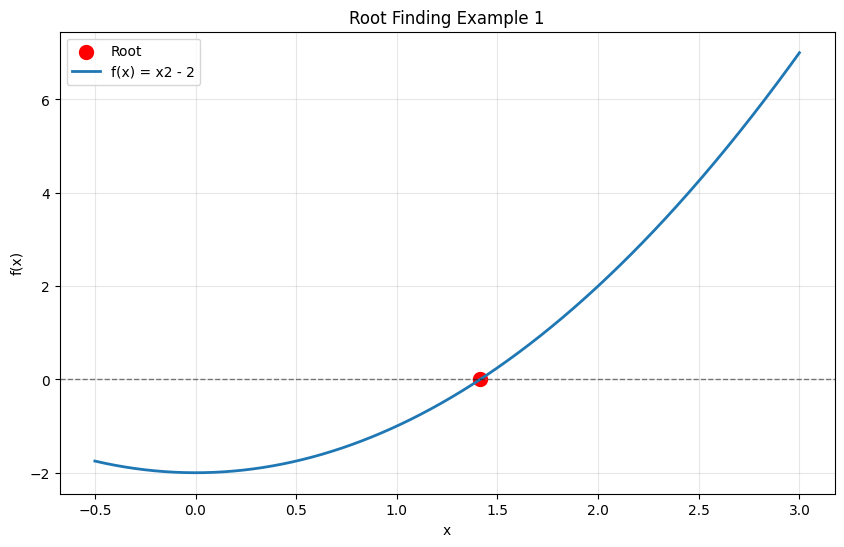

In [2]:
# Define the function
def quadratic(x):
    """f(x) = x^2 - 2"""
    return x * x - 2.0

quadratic_func = Func[Double, Double](quadratic)
root = Bisection.Solve(quadratic_func, 1.0, 0.0, 4.0)
root_brent = Brent.Solve(quadratic_func, 0.0, 4.0)
true_root = np.sqrt(2.0)

root_df = pd.DataFrame([
    {'Method': 'Bisection', 'Found Root': root, 'True Root': true_root, 'Abs Error': abs(root - true_root), 'f(root)': quadratic(root)},
    {'Method': 'Brent', 'Found Root': root_brent, 'True Root': true_root, 'Abs Error': abs(root_brent - true_root), 'f(root)': quadratic(root_brent)},
])
print('Root-finding results for f(x) = x2 - 2')
display(root_df)

x = np.linspace(-0.5, 3, 500)
y = [quadratic(xi) for xi in x]
plt.figure(figsize=(10, 6))
plt.scatter(np.sqrt(2),0, color = 'red', label = 'Root', linewidths=5)
plt.plot(x, y, linewidth=2, label='f(x) = x2 - 2')
plt.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
plt.xlabel('x'); plt.ylabel('f(x)'); plt.title('Root Finding Example 1'); plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

## Performance Comparison: Numerics vs SciPy
We take a look at how fast Numerics root finding methods are against the Python implementation in the "scipy package". Here Numerics is a little slower, but it still a comparable speed.

In [3]:
try:
    from scipy.optimize import root_scalar
    
    # Time Numerics
    start = time.perf_counter()
    root_numerics = Bisection.Solve(quadratic_func, 1, 0, 4)
    time_numerics = time.perf_counter() - start
    
    # Time SciPy
    start = time.perf_counter()
    result_scipy = root_scalar(quadratic, bracket=(1, 4), method='bisect', xtol=1e-8)
    root_scipy = result_scipy.root
    time_scipy = time.perf_counter() - start
    
    print("PERFORMANCE COMPARISON: Root Finding")
    print(f"Numerics Bisection:  {time_numerics*1000:.4f} ms  ->  root = {root_numerics:.10f}")
    print(f"SciPy Bisection:     {time_scipy*1000:.4f} ms  ->  root = {root_scipy:.10f}")
    print(f"Difference:          {abs(root_numerics - root_scipy):.2e}")
    
except ImportError:
    print("SciPy not installed. Skipping comparison.")

PERFORMANCE COMPARISON: Root Finding
Numerics Bisection:  0.7002 ms  ->  root = 1.4142135605
SciPy Bisection:     0.0922 ms  ->  root = 1.4142135661
Difference:          5.59e-09


## Additional Root Finding Examples

Let's try more complex functions.

Root-finding comparison table


,Function,Method,Root,f(root),Abs Error vs True
0,2sin(x)-3cos(x)-0.5,Bisection,1.121917,-7.880528e-09,2.984851e-05
1,2sin(x)-3cos(x)-0.5,Brent,1.121917,8.223644e-12,2.984630e-05
2,e^-x - x,Bisection,0.567143,-1.293185e-09,8.251863e-10
3,e^-x - x,Brent,0.567143,5.548373e-11,3.540435e-11


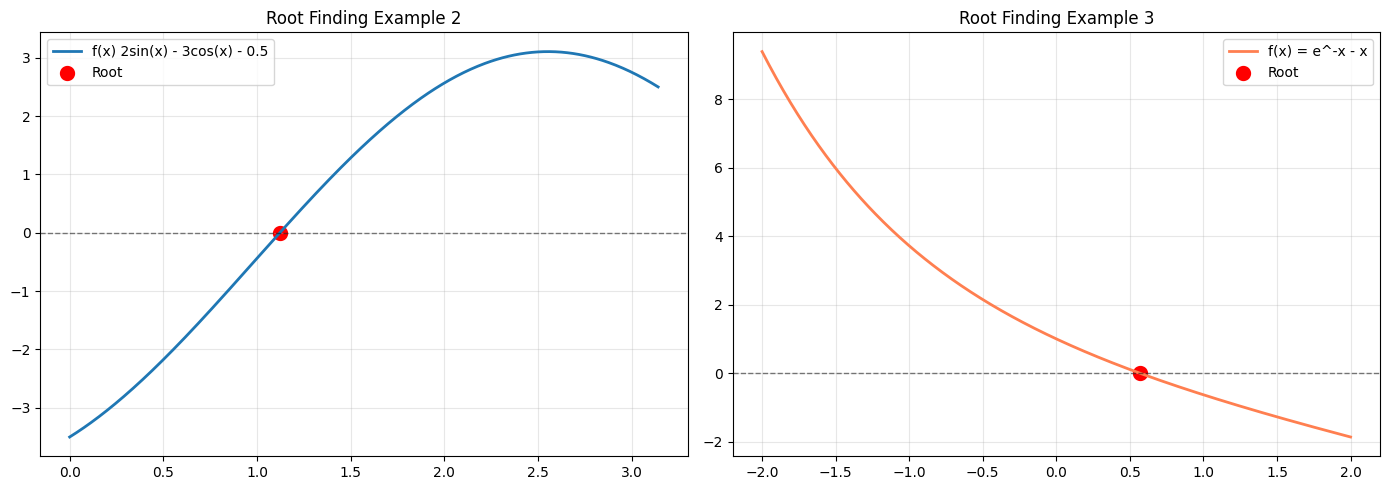

In [4]:
# Trigonometric function: 2sin(x) - 3cos(x) - 0.5
def trig_func(x):
    return 2*np.sin(x) - 3*np.cos(x) - 0.5

trig_func_net = Func[Double, Double](trig_func)
root_trig = Bisection.Solve(trig_func_net, 0.5, 0.0, np.pi)
root_trig_brent = Brent.Solve(trig_func_net, 0.0, np.pi)
true_root_trig = 1.1219469809174553

def exp_func(x):
    return np.exp(-x) - x

exp_func_net = Func[Double, Double](exp_func)
root_exp = Bisection.Solve(exp_func_net, 1.0, -2.0, 2.0)
root_exp_brent = Brent.Solve(exp_func_net, -2.0, 2.0)
true_root_exp = 0.5671432904097838

results_df = pd.DataFrame([
    {'Function': '2sin(x)-3cos(x)-0.5', 'Method': 'Bisection', 
     'Root': root_trig, 
     'f(root)': trig_func(root_trig), 
     'Abs Error vs True': abs(root_trig - true_root_trig)},
    {'Function': '2sin(x)-3cos(x)-0.5', 'Method': 'Brent',    
     'Root': root_trig_brent, 
     'f(root)': trig_func(root_trig_brent), 
     'Abs Error vs True': abs(root_trig_brent - true_root_trig)},
    {'Function': 'e^-x - x',           'Method': 'Bisection', 
     'Root': root_exp, 
     'f(root)': exp_func(root_exp), 
     'Abs Error vs True': abs(root_exp - true_root_exp)},
    {'Function': 'e^-x - x',           'Method': 'Brent',    
     'Root': root_exp_brent, 
     'f(root)': exp_func(root_exp_brent), 
     'Abs Error vs True': abs(root_exp_brent - true_root_exp)},
])

print('Root-finding comparison table')
display(results_df)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
x1 = np.linspace(0, np.pi, 500)
ax1.plot(x1, [trig_func(xi) for xi in x1], linewidth=2, label = 'f(x) 2sin(x) - 3cos(x) - 0.5' )
ax1.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax1.scatter(true_root_trig, 0, color = 'red', linewidths=5, label='Root')
ax1.set_title('Root Finding Example 2'); ax1.legend(); ax1.grid(True, alpha=0.3)
ax1.legend()

x2 = np.linspace(-2, 2, 500)
ax2.plot(x2, [exp_func(xi) for xi in x2], linewidth=2, color='coral', label = 'f(x) = e^-x - x')
ax2.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax2.scatter(true_root_exp, 0, color = 'red', linewidths=5, label = 'Root')
ax2.set_title('Root Finding Example 3'); ax2.legend(); ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout(); plt.show()

## Numerical Integration

Numerical integration, also known as numerical quadrature, is a fundamental technique for approximating definite integrals. It has wide-ranging applications in various scientific and engineering fields. For example, in statistics, the expected value of a random variable is calculated using an integral, and numerical integration can be employed to approximate this expected value. Many problems in engineering and physics cannot be solved analytically and must rely on numerical methods to approximate solutions.

### Single Dimension Integration

Numerics provides several methods for performing numerical integration on single dimensional integrands. Each algorithm computes an approximation to a definite integral of the form:

$$
I = \int\limits_{a}^{b}f(x) \cdot dx
$$

For the first example, let's consider a simple function with a single variable:

$$
f(x)=x^3
$$

Integrating from $a=0$ to $b=1$ yields the exact solution:

$$
\int\limits_{0}^{1}f(x) \cdot dx = \frac{1}{4}x^4 \biggr|_0^1 = \frac{1}{4} \cdot 1^4 - 0 = 0.25
$$

Definite integrals can be numerically solved using Riemann sums, such as the trapezoidal rule. This method works by approximating the region under the function $f(x)$ as a trapezoid and calculating its area:

$$
I =\int\limits_{0}^{1}f(x) \cdot  dx \approx \left(\frac{f(a) + f(b)}{2} \right)\cdot(b-a)
$$

This approximation can be improved by partitioning (or binning) the integration interval $[a,b]$ and then applying the trapezoidal rule to each subinterval and summing the results:

$$
I =\int\limits_{0}^{1}f(x) \cdot dx \approx \sum_{i=1}^{N} \left(\frac{f(x_{i-1}) + f(x_i)}{2} \right)\cdot(x_i-x_{i-1})
$$

### Methods Available
- Trapezoidal rule: Simple baseline method with linear convergence. 
- Gauss-Legendre quadrature: High accuracy for smooth functions with few evaluations.
- Simpson's rule: Higher-order rule using quadratic interpolation.
- Midpoint method: Simple and often slightly better than trapezoidal for smooth functions.

### Gauss-Legendre Quadrature

The Gauss-Legendre method uses optimal polynomial quadrature for smooth functions [[1]](#1). It evaluates the function at specific points (roots of Legendre polynomials) with corresponding weights to achieve high accuracy:

$$
\int_{-1}^{1} f(x)\,dx \approx \sum_{i=1}^{n} w_i f(x_i)
$$

where $x_i$ are roots of Legendre polynomials and $w_i$ are corresponding weights. Numerics provides both a 10-point and a 20-point Gauss-Legendre method.

Accuracy: The 10-point Gauss-Legendre method is exact for polynomials of degree 19 or less. For higher accuracy with non-polynomial smooth integrands, use the 20-point variant.

### Simpson's Rule

Simpson's Rule provides more accurate approximations than the Trapezoidal Rule by using quadratic interpolation. The formula approximates the region under the function $f(x)$ as a weighted average of the trapezoidal and midpoint methods:

$$
I =\int\limits_{a}^{b}f(x) \cdot dx \approx \left[f(a) + 4 \cdot f \left(\frac{a+b}{2} \right) + f(b) \right]\cdot \left(\frac{b-a}{6} \right)
$$

Similar to the Trapezoidal Rule, the accuracy is improved by partitioning the integration interval. 

Accuracy: Simpson's Rule is fourth-order accurate, $O(h^4)$, making it significantly more accurate than the Trapezoidal Rule for smooth functions.

### Midpoint Rule

The Midpoint Rule evaluates the function at the midpoint of each interval:
$$
I = \int_{a}^{b} f(x)\,dx \approx \sum_{i=1}^{n} f(x_i) \left( \frac{b-a}{n} \right)
$$
where $f(x_i)$ is the midpoint of the $i$ interval.

In [5]:
def f_x3(x):
    return x**3

f_x3_net = Func[Double, Double](f_x3)

gauss = Integration.GaussLegendre(f_x3_net, 0, 1)
trapz = Integration.TrapezoidalRule(f_x3_net, 0, 1, 1000)
simps = Integration.SimpsonsRule(f_x3_net, 0, 1, 1000)
midpt = Integration.Midpoint(f_x3_net, 0, 1, 1000)

true_value = 0.25
int_df = pd.DataFrame([
    {'Method':'Gauss-Legendre','Result':gauss,'Abs Error':abs(gauss-true_value)},
    {'Method':'Trapezoidal','Result':trapz,'Abs Error':abs(trapz-true_value)},
    {'Method':"Simpson's Rule",'Result':simps,'Abs Error':abs(simps-true_value)},
    {'Method':'Midpoint','Result':midpt,'Abs Error':abs(midpt-true_value)},
])
print('Integration of x^3 from 0 to 1')
display(int_df)

Integration of x^3 from 0 to 1


,Method,Result,Abs Error
0,Gauss-Legendre,0.25,0.000000e+00
1,Trapezoidal,0.25,2.500000e-07
2,Simpson's Rule,0.25,1.665335e-16
3,Midpoint,0.25,1.250000e-07


### Integration Performance: Numerics vs SciPy
We take a look at how fast Numerics integration methods are against Python's implementations in the "scipy" package. We can see that Numerics is a little slower, but the differences are comparable.

In [6]:
try:
    start = time.perf_counter()
    result_numerics_gauss = Integration.GaussLegendre(f_x3_net, 0, 1)
    time_numerics_gauss = time.perf_counter() - start
    start = time.perf_counter()
    result_numerics_simps = Integration.SimpsonsRule(f_x3_net, 0, 1, 1000)
    time_numerics_simps = time.perf_counter() - start

    start = time.perf_counter()
    result_scipy_quad, _ = integrate.quad(f_x3, 0, 1)
    time_scipy_quad = time.perf_counter() - start
    x_pts = np.linspace(0, 1, 1001)
    y_pts = [f_x3(xi) for xi in x_pts]
    start = time.perf_counter()
    result_scipy_simps = integrate.simpson(y_pts, x_pts)
    time_scipy_simps = time.perf_counter() - start

    perf_df = pd.DataFrame([
        {'Family':'Gauss/Quad','Library':'Numerics','Method':'Gauss-Legendre','Time (ms)':time_numerics_gauss*1000,'Result':result_numerics_gauss},
        {'Family':'Gauss/Quad','Library':'SciPy','Method':'quad','Time (ms)':time_scipy_quad*1000,'Result':result_scipy_quad},
        {'Family':'Simpson','Library':'Numerics','Method':'Simpson','Time (ms)':time_numerics_simps*1000,'Result':result_numerics_simps},
        {'Family':'Simpson','Library':'SciPy','Method':'simpson','Time (ms)':time_scipy_simps*1000,'Result':result_scipy_simps},
    ])
    print('Performance comparison: integration (Numerics vs SciPy)')
    display(perf_df)
except ImportError:
    print('SciPy not installed. Skipping comparison.')

Performance comparison: integration (Numerics vs SciPy)


,Family,Library,Method,Time (ms),Result
0,Gauss/Quad,Numerics,Gauss-Legendre,0.4430,0.25
1,Gauss/Quad,SciPy,quad,0.1094,0.25
2,Simpson,Numerics,Simpson,2.2830,0.25
3,Simpson,SciPy,simpson,0.1890,0.25


## Adaptive Integration
The challenge with static numerical integration methods, such as the trapezoidal rule mentioned above, is that the user must specify both the limits of integration and the number of integration bins. If the integrand function has subregions with high variance, this approach can lead to large approximation errors. Many real-world integrand functions have substantial weight concentrated in narrow subregions, resulting in wasted integration bins in areas that contribute little to the total weight.

Adaptive integration, a more refined numerical integration method, adjusts subintervals within the integration bounds based on the behavior of the function. These methods concentrate subintervals in regions that contribute the most to the integral, overcoming the limitations of static approaches.

### Methods
- Adaptive Gauss Lobatto
- Adaptive Gauss Kronrod
- Adaptive Simpson's Rule
- Adaptive Simpson's Rule 2D

### Adaptive Gauss-Lobatto

The Adaptive Gauss-Lobatto (AGL) method includes endpoints in quadrature nodes, making it useful for integrands with endpoint singularities [[4]](#4). The AGL method requires 18 function evaluations to converge given an absolute and relative tolerance of $1 \times 10^{-8}$.

### Adaptive Gauss-Kronrod

The Adaptive Gauss-Kronrod method pairs a 10-point Gauss rule with a 21-point Kronrod extension for error estimation [[4]](#4). This method efficiently reuses function evaluations to provide accurate error estimates.

Advantages: Efficient error estimation, reuses function evaluations from the Gauss rule in the Kronrod extension.

### Adaptive Simpson's Rule 

The Adaptive Simpson's Rule (ASR) algorithm subdivides the integration interval recursively until a user-defined tolerance is achieved. In each subinterval, Simpson's Rule is used to approximate the region under the function [[5]](#5). The criterion for determining when to stop subdividing an interval is:

$$
\frac{1}{15} \cdot \left| S(a, m) + S(m, b) - S(a,b) \right| \leq \epsilon + \epsilon \cdot \left| S(a, b) \right|
$$

where $[a,b]$ is the integration interval, $m = \frac{a+b}{2}$, $S(\cdot)$ represents Simpson's Rule evaluated at those intervals, and $\epsilon$ is the absolute and relative error tolerance for the interval. Each subinterval is recursively subdivided and evaluated until the specified tolerance is met.

In [7]:
# Adaptive integration demo using a challenging function
def adaptive_target(x):
    return np.exp(-x*x)

adaptive_target_net = Func[Double, Double](adaptive_target)

# Reference value using SciPy quad
ref_val, _ = integrate.quad(adaptive_target, -3, 3)

# Adaptive methods (Numerics.Integration namespace)
gk = AdaptiveGaussKronrod(adaptive_target_net, -3, 3)
gk.AbsoluteTolerance = 1e-8
gk.RelativeTolerance = 1e-8
gk.Integrate()

lob = AdaptiveGaussLobatto(adaptive_target_net, -3, 3)
lob.Integrate()

asim = AdaptiveSimpsonsRule(adaptive_target_net, -3, 3)
asim.AbsoluteTolerance = 1e-8
asim.RelativeTolerance = 1e-8
asim.Integrate()

rows = [
    {'Method':'Adaptive Gauss-Kronrod','Estimate':gk.Result,'Abs Error':abs(gk.Result-ref_val),'Std Error':gk.StandardError},
    {'Method':'Adaptive Gauss-Lobatto','Estimate':lob.Result,'Abs Error':abs(lob.Result-ref_val),'Std Error':np.nan},
    {'Method':'Adaptive Simpson','Estimate':asim.Result,'Abs Error':abs(asim.Result-ref_val),'Std Error':asim.StandardError},
]

adaptive_df = pd.DataFrame(rows)
print(f"Reference integral value (SciPy quad): {ref_val:.10f}")
display(adaptive_df)


Reference integral value (SciPy quad): 1.7724146965


,Method,Estimate,Abs Error,Std Error
0,Adaptive Gauss-Kronrod,1.772415,0.000000e+00,6.873728e-10
1,Adaptive Gauss-Lobatto,1.772415,1.074696e-13,NaN
2,Adaptive Simpson,1.772415,4.867884e-12,1.536564e-09


## When to Use Each Method
| Category | Method | Best Use |
|---|---|---|
| Root Finding | Bisection | Robust, bracketed roots |
| Root Finding | Brent | Faster than bisection, bracketed roots |
| Integration | Trapezoidal | Simple, smooth functions with many subintervals |
| Integration | Midpoint | Simple, low-order accuracy baseline |
| Integration | Simpson | Good accuracy/speed tradeoff |
| Integration | Gauss-Legendre | High accuracy for smooth functions |
| Integration | Gauss-Legendre (20-pt) | Higher-order accuracy for smooth functions |
| Integration | Adaptive Gauss-Lobatto | Adaptive-friendly node placement near endpoints |
| Integration | Adaptive Gauss-Kronrod | Error estimation via nested rules |
| Integration | Adaptive Simpson | Automatic refinement for difficult integrands |

## Summary
In this notebook you:     
  
$\checkmark$ Solved 1D root-finding problems with Bisection and Brent's method      
$\checkmark$ Applied fixed-step quadrature (Trapezoidal, Simpson, Gauss-Legendre)       
$\checkmark$ Used adaptive integration methods (Adaptive Gauss-Lobatto, Adaptive Gauss-Kronrod, Adaptive Simpson)     
$\checkmark$ Compared accuracy and robustness across methods

## Exercise
1. Solve a nonlinear root with both bisection and Brent and compare iterations 
2. Integrate a sharply peaked function and compare fixed vs adaptive rules
3. Tighten tolerance and observe cost/accuracy tradeoffs

## References

<a id="1">[1]</a> R. L. Burden and J. D. Faires, *Numerical Analysis*, 9th ed. Brooks/Cole, 2010.

<a id="2">[2]</a> R. P. Brent, *Algorithms for Minimization Without Derivatives*. Prentice-Hall, 1973.

<a id="3">[3]</a> E. Suli and D. Mayers, *An Introduction to Numerical Analysis*. Cambridge University Press, 2003.

<a id="4">[4]</a> R. Piessens, E. de Doncker-Kapenga, C. W. Ueberhuber, and D. K. Kahaner, *QUADPACK: A Subroutine Package for Automatic Integration*. Springer, 1983.

<a id="5">[5]</a> W. H. Press, S. A. Teukolsky, W. T. Vetterling, and B. P. Flannery, *Numerical Recipes: The Art of Scientific Computing*, 3rd ed. Cambridge University Press, 2007.
